# EMiF Project — Has the structure of risk in financial markets changed since COVID-19?

## Section 0 — Data loading and transformations

The goal of this section is to prepare a clean dataset that all subsequent sections will use without modification. Every transformation is documented and justified here.

This section produces the following objects:

- `prices` — daily prices, forward-filled, full sample, all 14 assets
- `yields` — daily level of the two rate series (US and German 10-year)
- `returns` — daily log-returns, full sample, 12 assets (rates excluded)
- `ret_pre` — log-returns, 2010–2020, main pre-COVID reference
- `ret_post` — log-returns, 2020–2026, post-COVID regime
- `ret_pre_full` — log-returns, 1990–2020, robustness checks only

### Why 2010–2020 as the pre-COVID reference period?

Taking everything before March 2020 as the pre-COVID period would include the Dot-com crash, 9/11 and the Global Financial Crisis, events that are themselves major structural breaks. A pre-COVID period that already contains three crises is not a meaningful benchmark for normality.

We instead use 2010–2020, a decade characterised by low interest rates, subdued volatility and a long equity bull market. This is the period investors and risk managers considered normal immediately before COVID. The full 1990–2020 sample is kept as `ret_pre_full` for robustness checks in the appendix.

### On the choice of breakpoint

We set the COVID breakpoint at 23 March 2020. This date corresponds to the S&P 500 market bottom and to the Federal Reserve announcement of unlimited quantitative easing. The VIX also peaked above 80 on that date, a level not reached since 2008. We are not studying the crash itself but the new risk regime that emerged after it, so the post-COVID period starts at the market low. Section 5 will test this choice statistically using the Bai-Perron procedure.

### 0.1 Libraries and global parameters

In [287]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_PATH      = "Data.xlsx"
SHEET          = "Feuil1"
ANNUALIZATION  = 252
COVID_BREAK    = "2020-03-23"
PRE_START      = "2010-01-01"
PRE_START_FULL = "1990-01-01"

RATE_SERIES = ["US T 10-year Yield", "German Gov 10-year yield"]

CATEGORIES = {
    "Equities"    : ["S&P500", "Eurostoxx 50", "Hang Seng", "MSCI EM", "SMI"],
    "Commodities" : ["Oil futures", "Gold"],
    "FX"          : ["EURUSD", "USDJPY", "USDCHF"],
    "Credit"      : ["US IG Bonds", "US HY Bonds"]
}

COLORS = {
    "pre"  : "steelblue",
    "post" : "firebrick",
    "full" : "dimgray"
}

FIG_DIR = Path("Figures")
TAB_DIR = Path("Tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "font.size"         : 11
})

### 0.2 Loading and cleaning the data

Missing values come from calendar mismatches between markets, US, European and Asian exchanges do not share the same holidays. The standard treatment is to forward-fill: the last observed price is carried forward until the next available observation, which is equivalent to assuming no trade and no new information on non-trading days.

Oil futures prices briefly turned negative in April 2020. Non-positive prices are treated as missing and forward-filled before computing log-returns.

Log-returns are defined as $r_{i,t} = \log(P_{i,t}) - \log(P_{i,t-1})$. They are preferred over simple returns because they are approximately stationary, time-additive and symmetric around zero, all properties required for ARCH and GARCH estimation.

Rate series are treated separately. The US and German 10-year yields are already expressed as rates, not prices. Computing log-differences on yields that approached zero as the German yield did between 2015 and 2020 produces values that are not economically meaningful. A yield moving from 0.10% to 0.05% generates a log-return of -69%, which bears no relationship to the actual market move. For this reason, rate series are stored separately as levels in `yields` and are used directly for visualisation and correlation analysis. They are not included in `returns`.

In [288]:
def load_data(path, sheet, rate_series, pre_start, pre_start_full, covid_break):

    raw = pd.read_excel(path, sheet_name=sheet, index_col=0, parse_dates=True)
    raw = raw.sort_index()

    missing_before = (raw.isnull().sum() / len(raw) * 100).round(1)

    prices = raw.where(raw > 0).ffill().dropna()

    yields  = prices[rate_series].copy()
    prices_ = prices.drop(columns=rate_series)

    returns = np.log(prices_).diff().dropna()

    ret_pre = returns.loc[
        pre_start : pd.Timestamp(covid_break) - pd.Timedelta(days=1)
    ]
    ret_post     = returns.loc[covid_break:]
    ret_pre_full = returns.loc[
        pre_start_full : pd.Timestamp(covid_break) - pd.Timedelta(days=1)
    ]

    return prices, yields, returns, ret_pre, ret_post, ret_pre_full, missing_before


prices, yields, returns, ret_pre, ret_post, ret_pre_full, missing_before = load_data(
    DATA_PATH, SHEET, RATE_SERIES, PRE_START, PRE_START_FULL, COVID_BREAK
)

print(f"Full sample    : {returns.index.min().date()} to {returns.index.max().date()} ({len(returns):,} obs)")
print(f"Pre-COVID      : {ret_pre.index.min().date()} to {ret_pre.index.max().date()} ({len(ret_pre):,} obs)")
print(f"Post-COVID     : {ret_post.index.min().date()} to {ret_post.index.max().date()} ({len(ret_post):,} obs)")
print(f"Pre-COVID full : {ret_pre_full.index.min().date()} to {ret_pre_full.index.max().date()} ({len(ret_pre_full):,} obs)")
print(f"\nAssets in returns ({len(returns.columns)}): {list(returns.columns)}")
print(f"Rate series in yields  ({len(yields.columns)}): {list(yields.columns)}")

Full sample    : 1990-01-04 to 2026-04-24 (9,597 obs)
Pre-COVID      : 2010-01-01 to 2020-03-20 (2,702 obs)
Post-COVID     : 2020-03-23 to 2026-04-24 (1,611 obs)
Pre-COVID full : 1990-01-04 to 2020-03-20 (7,986 obs)

Assets in returns (12): ['S&P500', 'Eurostoxx 50', 'Hang Seng', 'MSCI EM', 'SMI', 'Oil futures', 'Gold', 'EURUSD', 'USDJPY', 'US IG Bonds', 'US HY Bonds', 'USDCHF']
Rate series in yields  (2): ['US T 10-year Yield', 'German Gov 10-year yield']


### 0.3 Dataset overview

In [289]:
print("Missing values before treatment (%):\n")
print(missing_before.to_string())
missing_before.to_csv(TAB_DIR / "tab0_missing_values.csv")

Missing values before treatment (%):

S&P500                      4.7
Eurostoxx 50                2.7
Hang Seng                   6.7
MSCI EM                     1.3
SMI                         4.9
US T 10-year Yield          5.5
German Gov 10-year yield    4.1
Oil futures                 7.1
Gold                        1.9
EURUSD                      2.1
USDJPY                      1.3
US IG Bonds                 1.5
US HY Bonds                 1.6
USDCHF                      1.3


In [290]:
print("Assets in returns:\n")
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    print(f"  {cat:15}: {', '.join(available)}")

print(f"\nRate series (stored as levels in yields):")
for r in RATE_SERIES:
    print(f"  {r}")

Assets in returns:

  Equities       : S&P500, Eurostoxx 50, Hang Seng, MSCI EM, SMI
  Commodities    : Oil futures, Gold
  FX             : EURUSD, USDJPY, USDCHF
  Credit         : US IG Bonds, US HY Bonds

Rate series (stored as levels in yields):
  US T 10-year Yield
  German Gov 10-year yield


### 0.4 Cumulative returns and yield levels

The following charts give a first visual overview of the full sample since 1990. Each panel covers one asset class. The vertical dashed line marks the COVID breakpoint at 23 March 2020. Rate series are displayed as yield levels rather than cumulative returns, which is the economically meaningful representation for interest rates.

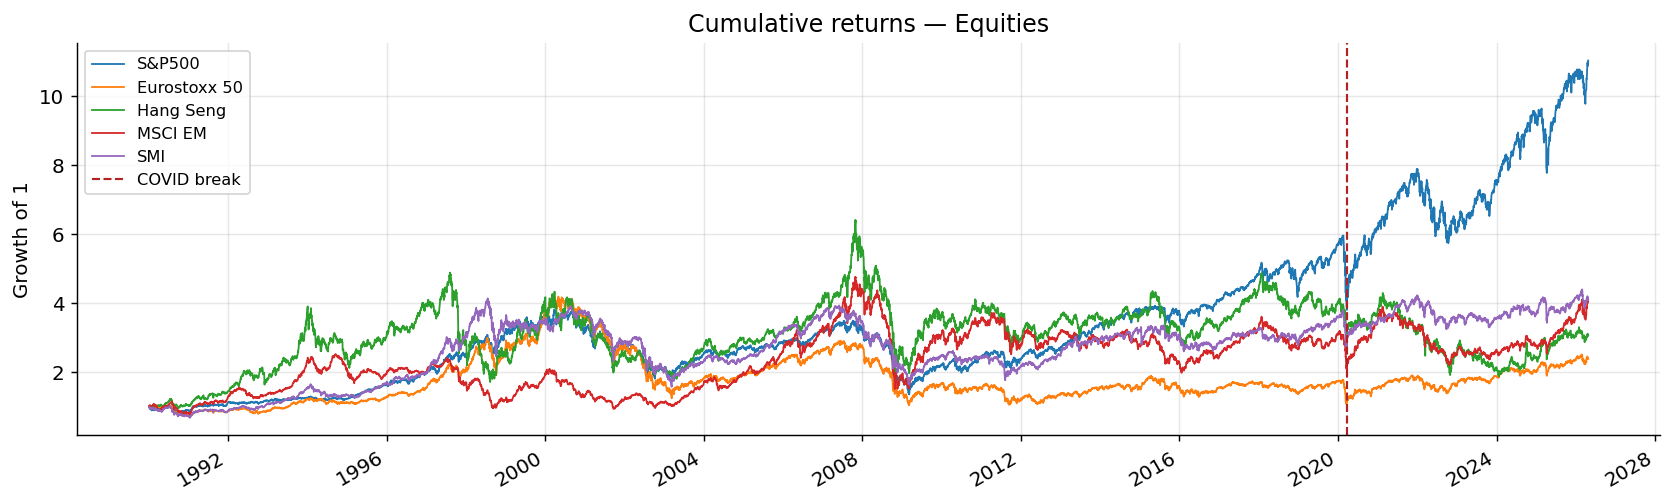

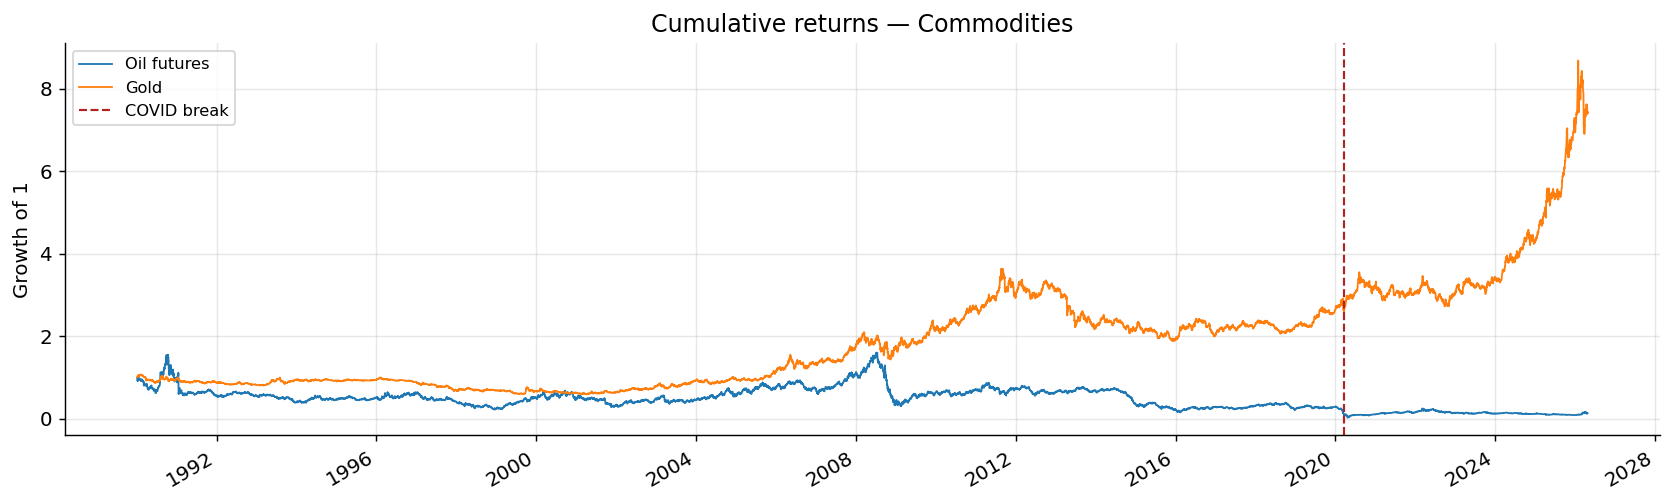

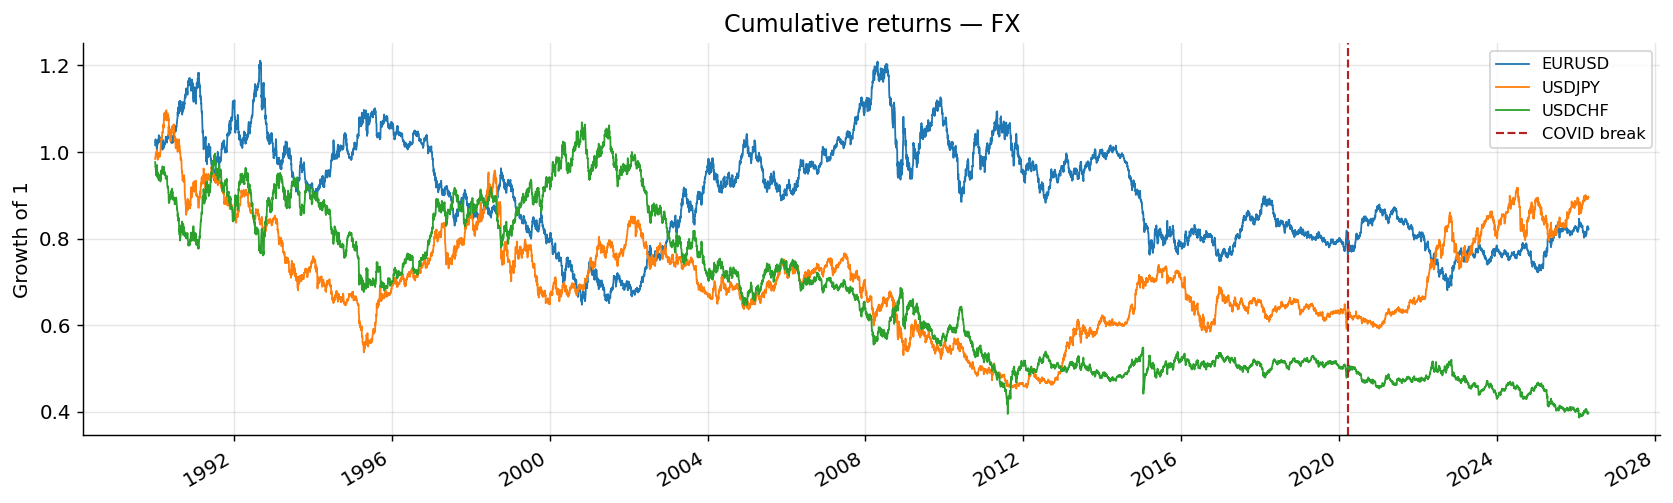

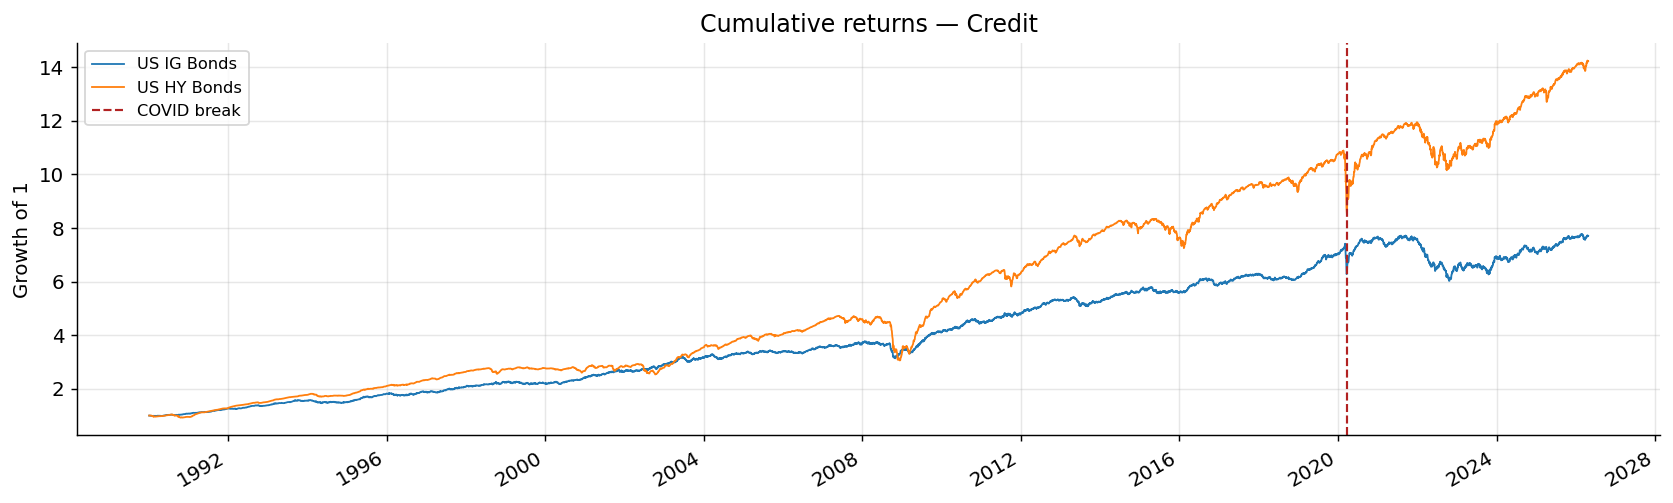

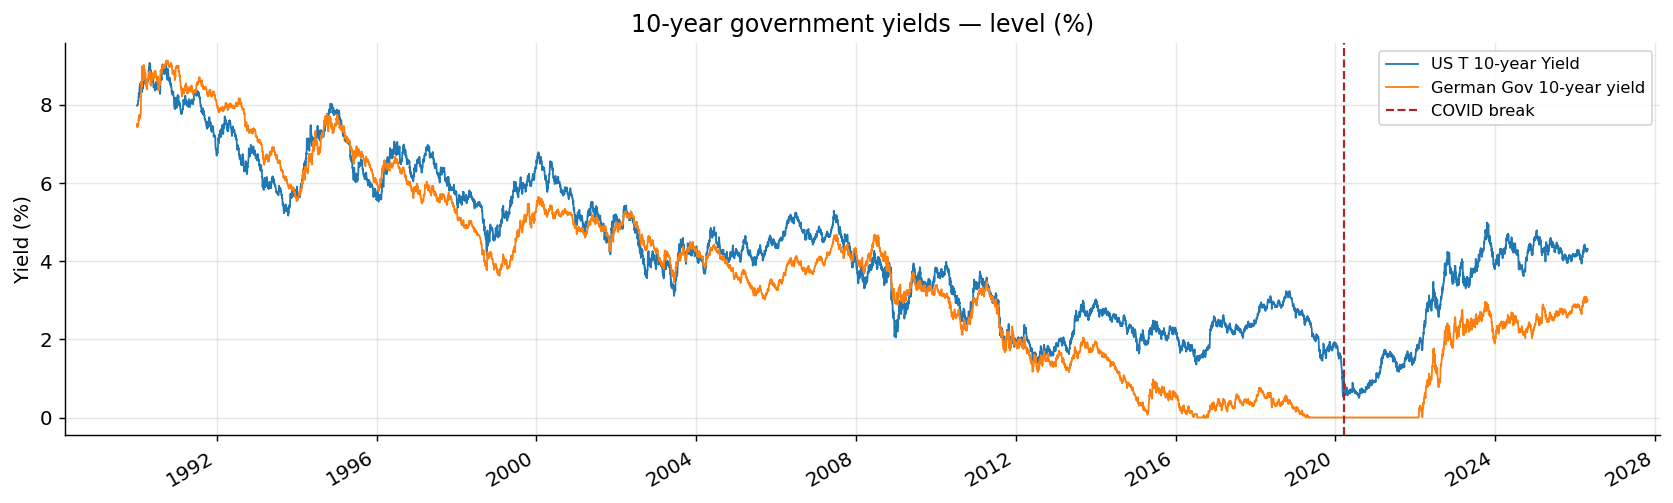

In [291]:
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    cum = (1 + returns[available]).cumprod()

    fig, ax = plt.subplots(figsize=(13, 4))
    cum.plot(ax=ax, linewidth=1)
    ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
               linestyle="--", linewidth=1.2, label="COVID break")
    ax.set_title(f"Cumulative returns — {cat}")
    ax.set_ylabel("Growth of 1")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig0_cumret_{cat.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
yields.plot(ax=ax, linewidth=1)
ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
           linestyle="--", linewidth=1.2, label="COVID break")
ax.set_title("10-year government yields — level (%)")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_yields_level.png", dpi=150, bbox_inches="tight")
plt.show()

### 0.5 Descriptive statistics

Before running any model, we compare the first four moments of each return series across the two periods. Annualised volatility measures the level of risk. Skewness measures asymmetry and left-tail exposure. Excess kurtosis measures tail thickness relative to a Gaussian distribution. The minimum daily return captures the worst tail event in each period.

In [292]:
def desc_stats(ret):
    return pd.DataFrame({
        "Ann. Vol (%)"   : (ret.std() * np.sqrt(ANNUALIZATION) * 100).round(2),
        "Skewness"       : ret.apply(stats.skew).round(3),
        "Kurt. (excess)" : ret.apply(stats.kurtosis).round(3),
        "Min return (%)" : (ret.min() * 100).round(2),
    })

combined = pd.concat(
    [desc_stats(ret_pre), desc_stats(ret_post)],
    axis=1,
    keys=["Pre-COVID (2010-2020)", "Post-COVID (2020-2026)"]
)
combined.to_csv(TAB_DIR / "tab0_descriptive_stats.csv")
combined

Pre-COVID (2010-2020)                                         \
                      Ann. Vol (%) Skewness Kurt. (excess) Min return (%)   
S&P500                       16.29   -1.358         19.204         -12.77   
Eurostoxx 50                 20.12   -0.747          9.275         -13.24   
Hang Seng                    17.72   -0.336          2.724          -6.02   
MSCI EM                      15.68   -0.695          4.744          -6.94   
SMI                          15.17   -1.112         10.911         -10.13   
Oil futures                  35.51   -1.169         23.672         -28.22   
Gold                         15.10   -0.648          6.430          -9.51   
EURUSD                        8.73   -0.026          1.891          -2.41   
USDJPY                        9.06   -0.018          5.118          -3.78   
US IG Bonds                   4.49   -1.904         18.531          -3.83   
US HY Bonds                   4.32   -4.323         49.492          -3.68   
USDCHF                       11.10   -7.104        229.310         -19.38   

             Post-COVID (2020-2026)                                         
                       Ann. Vol (%) Skewness Kurt. (excess) Min return (%)  
S&P500                        17.86    0.320          8.199          -6.16  
Eurostoxx 50                  18.38    0.176          5.479          -5.09  
Hang Seng                     23.82   -0.373          7.872         -14.18  
MSCI EM                       16.68   -0.263          5.066          -8.25  
SMI                           13.97   -0.310          6.212          -5.52  
Oil futures                   52.89   -3.141         78.893         -60.17  
Gold                          17.20   -0.667          6.606          -9.37  
EURUSD                         7.33    0.219          1.547          -1.86  
USDJPY                         9.13   -0.565          4.020          -3.86  
US IG Bonds                    5.88    0.083          1.933          -1.80  
US HY Bonds                    5.31    0.882         16.096          -2.39  
USDCHF                         7.76   -0.689          4.448          -3.91

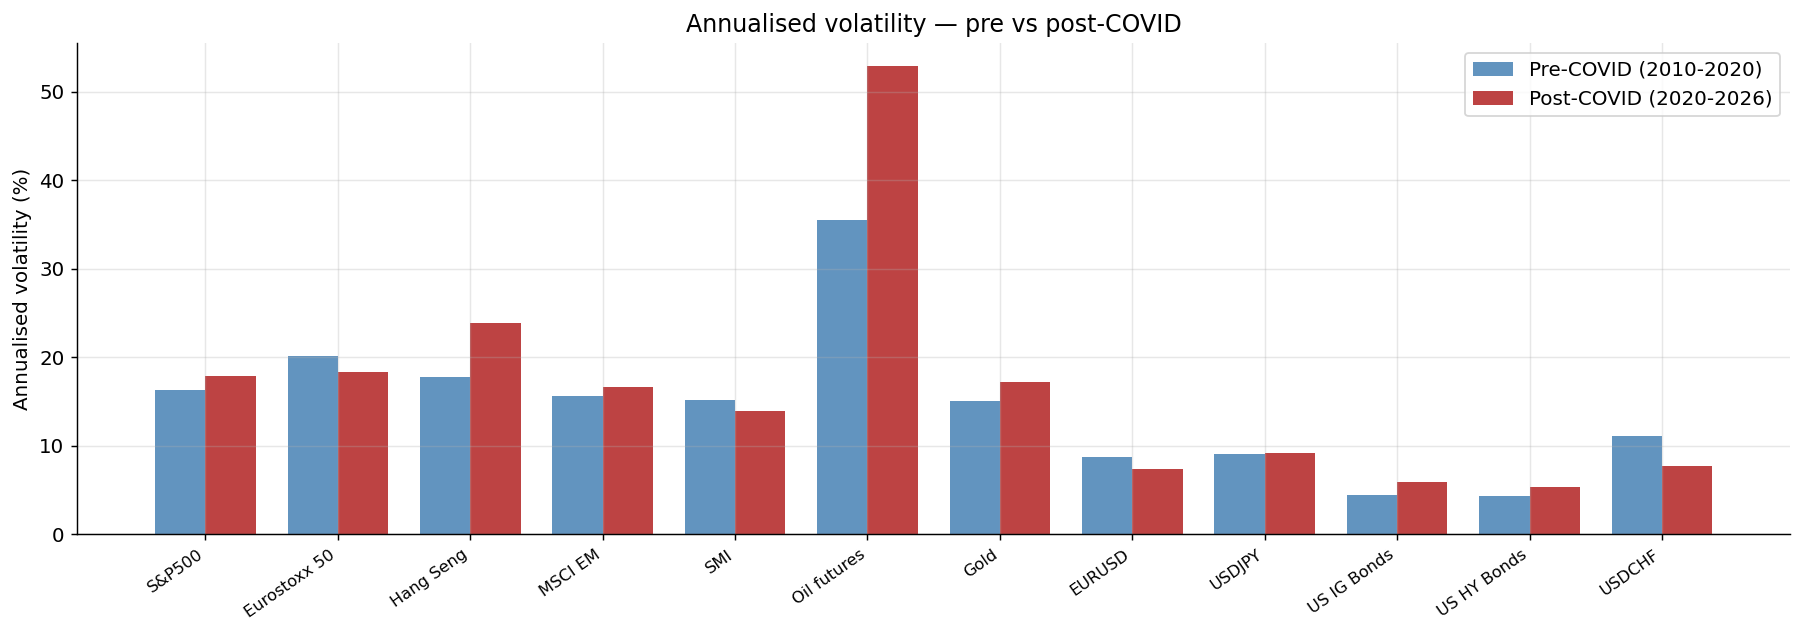

In [293]:
vol_pre  = ret_pre.std()  * np.sqrt(ANNUALIZATION) * 100
vol_post = ret_post.std() * np.sqrt(ANNUALIZATION) * 100

x     = np.arange(len(returns.columns))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID (2010-2020)",
       color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, vol_post, width, label="Post-COVID (2020-2026)",
       color=COLORS["post"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(returns.columns), rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Annualised volatility (%)")
ax.set_title("Annualised volatility — pre vs post-COVID")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_vol_comparison.png", dpi=150, bbox_inches="tight")
plt.show()